Assignment 10: Create images based on text prompts using a text-to-image model to explore Transformer
capabilities in multimodal tasks.

Install Required Libraries

In [50]:
!pip install diffusers transformers accelerate torch matplotlib

Import Libraries

In [51]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

Load the Pre-trained Text-to-Image Model

In [52]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Define Text Prompts

In [53]:
prompts = [
    "A futuristic AI robot teaching students in a digital classroom",
    "A fantasy dragon flying over a medieval castle, cinematic lighting",
    "Astronaut riding a horse on Mars, surreal art",
    "Ancient temple hidden inside a glowing jungle, ultra detailed"
]

Generate Images from Text

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

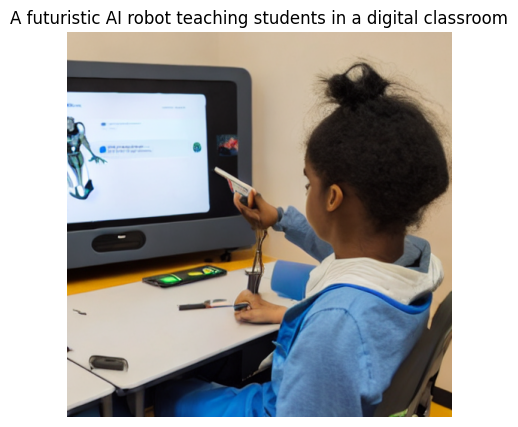

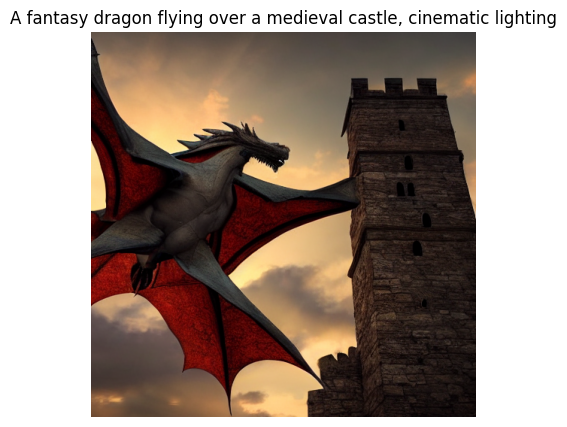

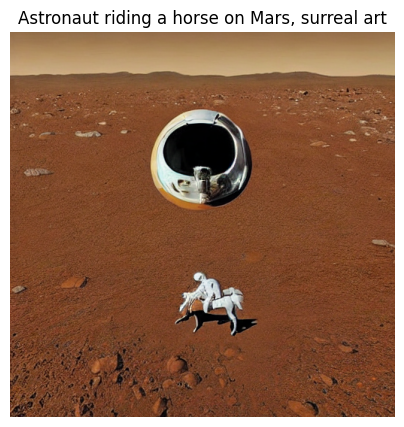

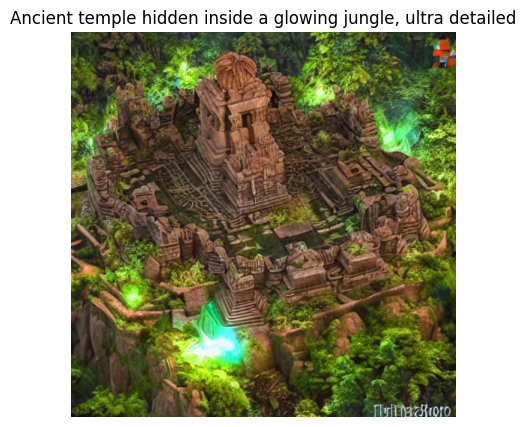

In [54]:
images = []

for prompt in prompts:

    image = pipe(prompt).images[0]

    images.append(image)

    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(prompt)

Save Generated Images

In [55]:
for i, img in enumerate(images):

    filename = f"generated_image_{i+1}.png"
    img.save(filename)

    print(f"Saved {filename}")

Saved generated_image_1.png
Saved generated_image_2.png
Saved generated_image_3.png
Saved generated_image_4.png


Generate Higher-Quality Images

  0%|          | 0/50 [00:00<?, ?it/s]

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

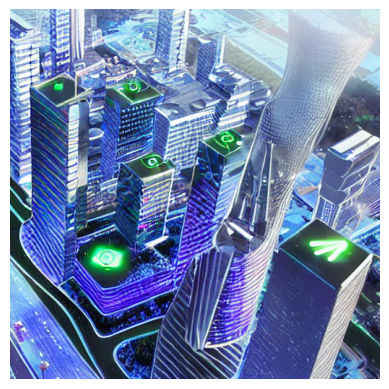

In [56]:
prompt = "A futuristic smart city powered by artificial intelligence"

image = pipe(
    prompt,
    num_inference_steps=50,
    guidance_scale=8
).images[0]

plt.imshow(image)
plt.axis("off")